# Case Studies: SARS-CoV-2 in a Hospital (Part 3)

## Introduction

In Parts 1 and 2 we used a basic **SIR model** (Susceptible → Infected → Recovered) on various network types, treating all agents uniformly. Here we move to a more realistic scenario:

> **A hospital ward with 1,000 individuals: patients and healthcare workers (HCWs).**

Two features make this setting more complex:

1. **Hospitalization dynamics (SIHR model)** — infected individuals may be hospitalized before recovering. Hospitalized agents do not transmit further.
2. **Contact-rate heterogeneity** — HCWs have *high contact rates* (they move between patients) while patients have *low contact rates*. This asymmetry shapes who drives the outbreak.
3. **Adaptive intervention: PPE adoption** — as hospitalizations become visible, HCWs adopt personal protective equipment (PPE), effectively switching from high- to low-contact behavior. This is a *negative feedback loop* that dampens the outbreak.

### Model compartments

| Symbol | Meaning |
|--------|---------|
| **S** | Susceptible — not yet infected |
| **I** | Infected — infectious, circulating |
| **H** | Hospitalized — removed from transmission |
| **R** | Recovered — immune |

### Agent properties

- `contact_rate = :high` — HCW: transmits at `trans_prob` per susceptible neighbor per step
- `contact_rate = :low` — Patient: transmits at `trans_prob × low_risk_factor`

## Setup

In [35]:
cd(@__DIR__)

# Per-notebook output directories
const FIGURES_DIR = "figures/part3"
const DATA_DIR    = "data/part3"

mkpath(FIGURES_DIR)
mkpath(DATA_DIR)
mkpath("output")

using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

using Agents, Graphs, Random, Plots, DataFrames, CSV,
      Statistics, StatsBase, StatsPlots, Measures

include("src/create_graph.jl")

@agent struct Person(GraphAgent)
    status::Symbol       = :S
    days_infected::Int   = 0
    contact_rate::Symbol = :high
end

include("src/initialize.jl")
include("src/agent_step.jl")

function model_step!(model::AgentBasedModel)
    model.susceptible_count  = sum(model[i].status == :S for i in 1:nv(model.graph))
    model.infected_count     = sum(model[i].status == :I for i in 1:nv(model.graph))
    model.hospitalized_count = sum(model[i].status == :H for i in 1:nv(model.graph))
    model.recovered_count    = sum(model[i].status == :R for i in 1:nv(model.graph))
end

  Activating project at `c:\Users\Leonard\julia-workspace\espidam-tutorial-2026`


model_step! (generic function with 1 method)

---
## Section A: Baseline Hospital Outbreak (SIHR Model)

We begin with a simple baseline: all agents have a **high contact rate** (homogeneous population) on a **preferential-attachment network** (a few highly-connected HCW hubs bridge many patient clusters).

The SIHR model adds a hospitalization stage: with probability `hospitalization_prob`, a newly infected agent becomes hospitalized on day 1 rather than circulating. Hospitalized agents recover faster (`days_to_hospital_recovery`) but do not transmit.

We compare:
- **SIR** (`use_hospitalization=false`): everyone circulates until recovery
- **SIHR** (`use_hospitalization=true`): a fraction are removed to hospital immediately

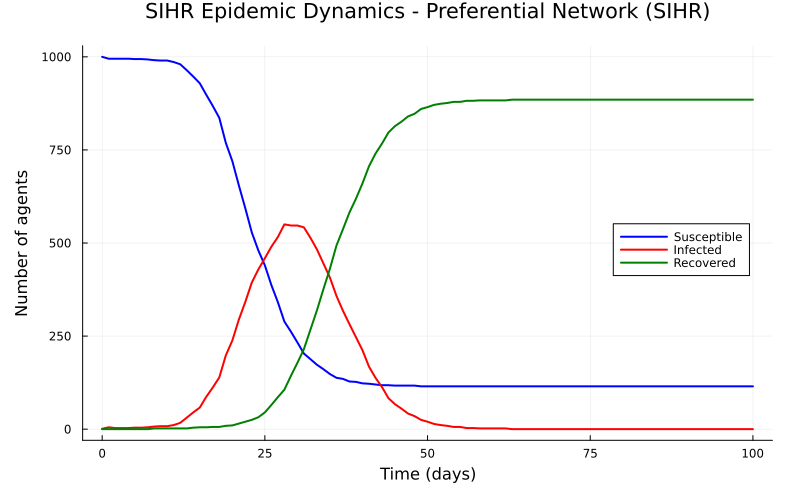

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\baseline_sihr.pdf"

In [36]:
include("src/plotting.jl")

model_sihr = initialize(;
    network_type=:preferential,
    mean_degree=4,
    patient_zero=:maxdegree,
    use_hospitalization=true,
    hospitalization_prob=0.15,
    days_to_hospital_recovery=7,
)

adata = [:status]
mdata = [:susceptible_count, :infected_count, :hospitalized_count, :recovered_count]
_, mdf_sihr = run!(model_sihr, 100; adata, mdata)

p_sihr = plot_epidemic_trajectories(mdf_sihr, :preferential; title_suffix=" (SIHR)")
display(p_sihr)
savefig(p_sihr, joinpath(FIGURES_DIR, "baseline_sihr.pdf"))

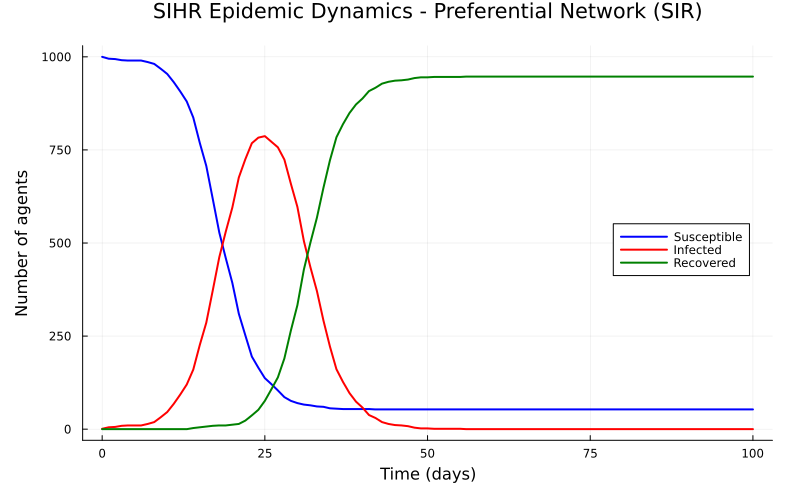

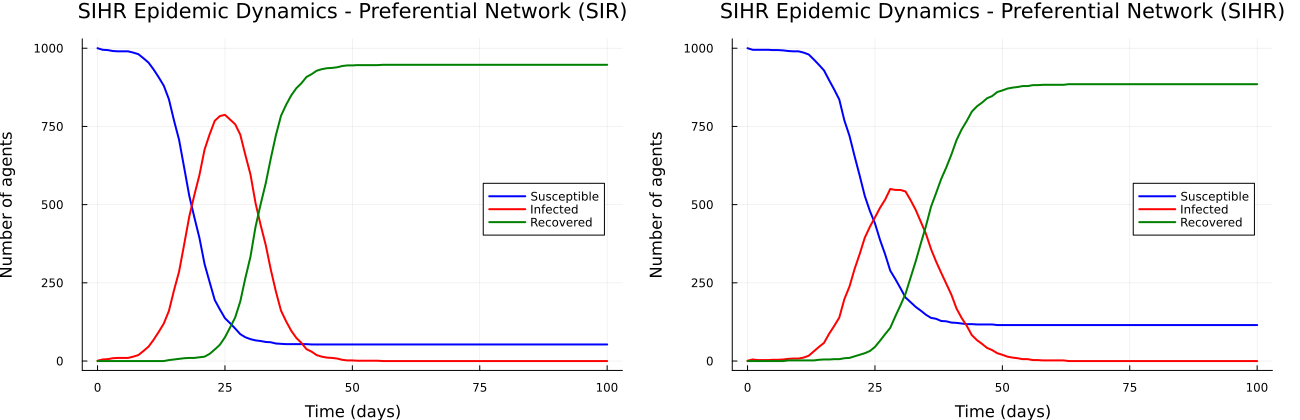

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\sir_vs_sihr.pdf"

In [37]:
model_sir = initialize(;
    network_type=:preferential,
    mean_degree=4,
    patient_zero=:maxdegree,
    use_hospitalization=false,
)

mdata_sir = [:susceptible_count, :infected_count, :recovered_count]
_, mdf_sir = run!(model_sir, 100; adata, mdata=mdata_sir)

p_sir = plot_epidemic_trajectories(mdf_sir, :preferential; title_suffix=" (SIR)")
display(p_sir)

p_compare = plot(p_sir, p_sihr, layout=(1,2), size=(1300, 420), margin=5Measures.mm)
display(p_compare)
savefig(p_compare, joinpath(FIGURES_DIR, "sir_vs_sihr.pdf"))

**Observation:** In SIHR, a fraction of infected agents are immediately removed to hospital and stop transmitting. This typically lowers the peak infection count and may shorten the epidemic relative to SIR, though the total recovered count (including hospitalized) remains similar.

---
## Section B: Risk Heterogeneity — Where Are the HCWs?

Now we introduce **contact-rate heterogeneity**: 10% of agents are HCWs (`contact_rate = :high`) and 90% are patients (`contact_rate = :low`). Patients transmit at `low_risk_factor = 0.3` times the HCW rate — reflecting PPE use or reduced mobility.

The key question: **does the placement of HCWs on the network change the outbreak?**

We compare three HCW placement strategies:
- `:random` — HCWs placed at random nodes
- `:maxdegree` — HCWs placed at the most-connected nodes (hubs)
- `:maxbetweenness` — HCWs placed at nodes on the most shortest paths (bridges)

The hypothesis: placing high-contact HCWs at central nodes creates super-spreaders and accelerates the epidemic.

In [38]:
include("src/run_simulations.jl")
include("src/plotting.jl")

# Common parameters for all placement strategies
hcw_params = (
    network_type    = :preferential,
    mean_degree     = 4,
    fraction_high_contact = 0.1,
    low_risk_factor = 0.3,
    patient_zero    = :maxdegree,
    use_hospitalization = true,
)

results_placement = Dict()
for strategy in [:random, :maxdegree, :maxbetweenness]
    println("Running simulations for high_contact=$(strategy)...")
    results_placement[strategy] = run_simulations(;
        hcw_params...,
        high_contact=strategy,
    )
end
println("Done.")

Running simulations for high_contact=random...
Running simulations for high_contact=maxdegree...
Running simulations for high_contact=maxbetweenness...
Done.


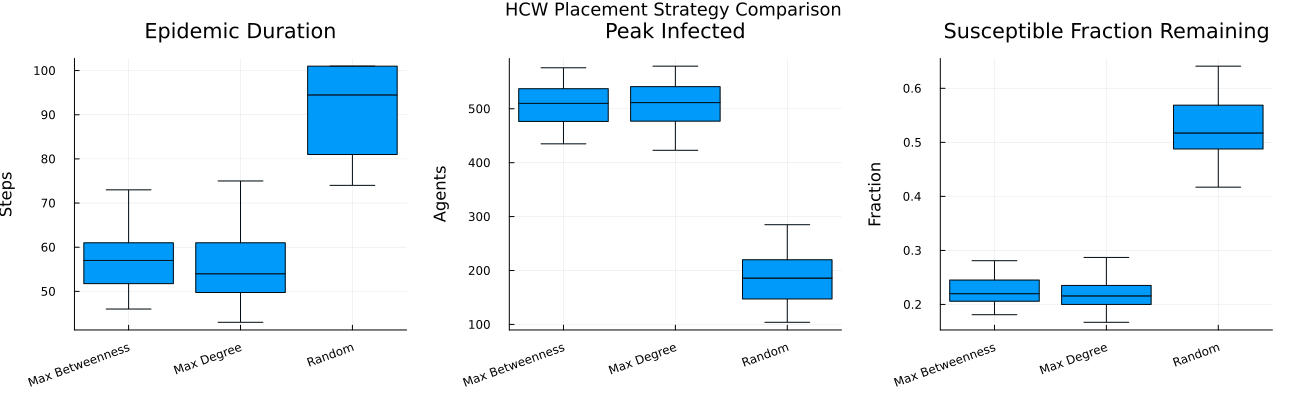

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\hcw_placement.pdf"

In [39]:
placement_labels = ["Random", "Max Degree", "Max Betweenness"]
strategies = [:random, :maxdegree, :maxbetweenness]

duration_data = DataFrame(value=Float64[], placement=String[])
maxinf_data   = DataFrame(value=Float64[], placement=String[])
sfr_data      = DataFrame(value=Float64[], placement=String[])

for (strategy, label) in zip(strategies, placement_labels)
    mdf = results_placement[strategy]
    grouped = groupby(mdf, :seed)
    for gdf in grouped
        first_inf = findfirst(gdf.infected_count .> 0)
        last_inf  = findlast(gdf.infected_count .> 0)
        dur = isnothing(last_inf) ? nrow(gdf) : last_inf - first_inf + 1
        push!(duration_data, (dur, label))
        push!(maxinf_data,   (maximum(gdf.infected_count), label))
        last_row = last(gdf)
        total = last_row.susceptible_count + last_row.infected_count +
                last_row.hospitalized_count + last_row.recovered_count
        push!(sfr_data, (last_row.susceptible_count / total, label))
    end
end

bp1 = boxplot(duration_data.placement, duration_data.value;
    title="Epidemic Duration", ylabel="Steps", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)
bp2 = boxplot(maxinf_data.placement, maxinf_data.value;
    title="Peak Infected", ylabel="Agents", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)
bp3 = boxplot(sfr_data.placement, sfr_data.value;
    title="Susceptible Fraction Remaining", ylabel="Fraction", legend=false,
    outliers=false, xrotation=20, margin=5Measures.mm)

p_placement = plot(bp1, bp2, bp3, layout=(1,3), size=(1300, 400),
    plot_title="HCW Placement Strategy Comparison", plot_titlefontsize=12,
    bottom_margin=10Measures.mm)
display(p_placement)
savefig(p_placement, joinpath(FIGURES_DIR, "hcw_placement.pdf"))

---
## Section C: Sensitivity to HCW Fraction and Patient Transmission Rate

How sensitive are the outbreak dynamics to:
1. **HCW fraction** (`fraction_high_contact`): what share of the population are healthcare workers?
2. **Patient transmission rate** (`low_risk_factor`): how much do patients contribute to spread relative to HCWs?

We sweep both parameters and look at the peak number of hospitalized agents — a proxy for healthcare system burden.

In [40]:
# Parameter sweep: fraction_high_contact × low_risk_factor
hcw_fractions  = [0.05, 0.10, 0.15, 0.20, 0.25]
low_risk_factors = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]

peak_hosp_matrix = zeros(length(hcw_fractions), length(low_risk_factors))

for (i, fhc) in enumerate(hcw_fractions)
    for (j, lrf) in enumerate(low_risk_factors)
        println("fraction_high_contact=$(fhc), low_risk_factor=$(lrf)")
        mdf = run_simulations(;
            network_type=:preferential,
            mean_degree=4,
            high_contact=:maxdegree,
            fraction_high_contact=Float64(fhc),
            low_risk_factor=Float64(lrf),
            patient_zero=:maxdegree,
            use_hospitalization=true,
        )
        # Mean peak hospitalized across seeds
        peak_hosp_matrix[i, j] = mean(
            combine(groupby(mdf, :seed), :hospitalized_count => maximum => :peak).peak
        )
    end
end
println("Sweep complete.")

fraction_high_contact=0.05, low_risk_factor=0.1
fraction_high_contact=0.05, low_risk_factor=0.2
fraction_high_contact=0.05, low_risk_factor=0.4
fraction_high_contact=0.05, low_risk_factor=0.6
fraction_high_contact=0.05, low_risk_factor=0.8
fraction_high_contact=0.05, low_risk_factor=1.0
fraction_high_contact=0.1, low_risk_factor=0.1
fraction_high_contact=0.1, low_risk_factor=0.2
fraction_high_contact=0.1, low_risk_factor=0.4
fraction_high_contact=0.1, low_risk_factor=0.6
fraction_high_contact=0.1, low_risk_factor=0.8
fraction_high_contact=0.1, low_risk_factor=1.0
fraction_high_contact=0.15, low_risk_factor=0.1
fraction_high_contact=0.15, low_risk_factor=0.2
fraction_high_contact=0.15, low_risk_factor=0.4
fraction_high_contact=0.15, low_risk_factor=0.6
fraction_high_contact=0.15, low_risk_factor=0.8
fraction_high_contact=0.15, low_risk_factor=1.0
fraction_high_contact=0.2, low_risk_factor=0.1
fraction_high_contact=0.2, low_risk_factor=0.2
fraction_high_contact=0.2, low_risk_factor=0.4
f

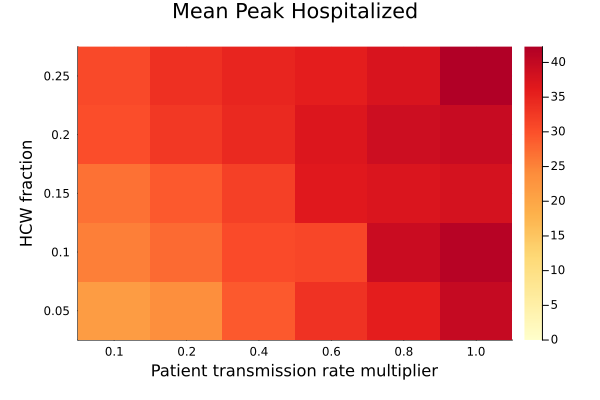

In [41]:
p_heatmap = heatmap(
    string.(low_risk_factors), string.(hcw_fractions), peak_hosp_matrix;
    xlabel="Patient transmission rate multiplier",
    ylabel="HCW fraction",
    title="Mean Peak Hospitalized",
    color=:YlOrRd,
    size=(600, 400),
    margin=5Measures.mm,
    clims=(0, maximum(peak_hosp_matrix)),
)

---
## Section D: PPE Adoption as an Adaptive Intervention

In reality, healthcare workers respond to the outbreak: as hospitalizations become visible, they adopt PPE, effectively reducing their transmission rate. We model this as a **dynamic risk-switching** mechanism:

> Each time step, a susceptible HCW (`contact_rate = :high`) switches to `contact_rate = :low` with probability `hospitalization_rate × risk_switch_rate`, where `hospitalization_rate = hospitalized_count / n_nodes`.

This creates a negative feedback loop:
- ↑ hospitalizations → ↑ PPE adoption → ↓ transmission → ↓ hospitalizations

We compare three scenarios:
- `risk_switch_rate = 0.0` — no PPE adoption (baseline)
- `risk_switch_rate = 5.0` — moderate PPE adoption
- `risk_switch_rate = 20.0` — rapid PPE adoption

**Hypothesis:** Higher `risk_switch_rate` flattens the hospitalization curve and reduces peak burden.

In [42]:
# Run simulations for different PPE adoption speeds
switch_rates = [0.0, 5.0, 20.0]
switch_labels = ["No PPE (rate=0)", "Moderate PPE (rate=5)", "Rapid PPE (rate=20)"]

results_ppe = Dict()
for rate in switch_rates
    println("Running risk_switch_rate=$(rate)...")
    results_ppe[rate] = run_simulations(;
        network_type=:preferential,
        mean_degree=4,
        high_contact=:maxdegree,
        fraction_high_contact=0.1,
        low_risk_factor=0.1,
        patient_zero=:maxdegree,
        use_hospitalization=true,
        use_risk_switching=(rate > 0.0),
        risk_switch_rate=Float64(rate),
    )
end
println("Done.")

Running risk_switch_rate=0.0...
Running risk_switch_rate=5.0...
Running risk_switch_rate=20.0...
Done.


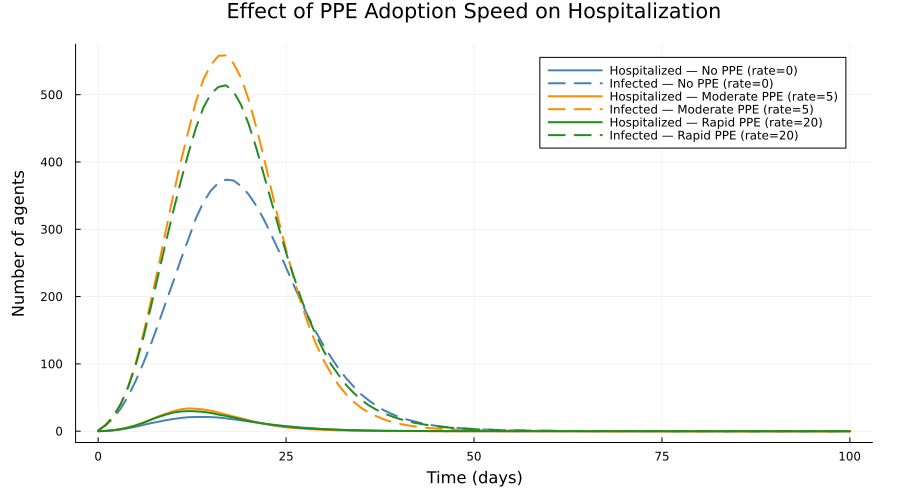

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\ppe_adoption.pdf"

In [43]:
colors = [:steelblue, :darkorange, :forestgreen]
p_ppe = plot(size=(900, 500), xlabel="Time (days)", ylabel="Number of agents",
    title="Effect of PPE Adoption Speed on Hospitalization",
    legend=:topright, margin=5Measures.mm)

for (rate, label, col) in zip(switch_rates, switch_labels, colors)
    mdf = results_ppe[rate]
    mean_traj = combine(groupby(mdf, :time),
        :hospitalized_count => mean => :mean_hosp,
        :infected_count     => mean => :mean_inf,
    )
    sort!(mean_traj, :time)
    plot!(p_ppe, mean_traj.time, mean_traj.mean_hosp;
        label="Hospitalized — $(label)", linewidth=2, color=col)
    plot!(p_ppe, mean_traj.time, mean_traj.mean_inf;
        label="Infected — $(label)", linewidth=2, color=col, linestyle=:dash)
end

display(p_ppe)
savefig(p_ppe, joinpath(FIGURES_DIR, "ppe_adoption.pdf"))

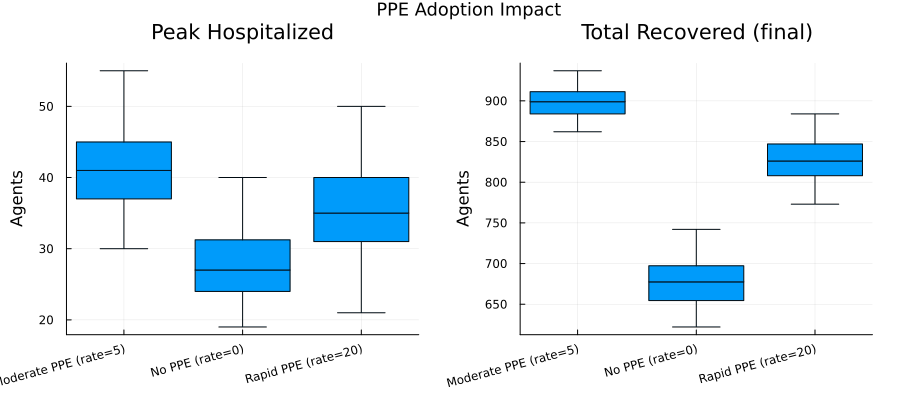

"c:\\Users\\Leonard\\julia-workspace\\espidam-tutorial-2026\\figures\\part3\\ppe_boxes.pdf"

In [44]:
peak_hosp_ppe = DataFrame(value=Float64[], scenario=String[])
total_rec_ppe = DataFrame(value=Float64[], scenario=String[])

for (rate, label) in zip(switch_rates, switch_labels)
    mdf = results_ppe[rate]
    for gdf in groupby(mdf, :seed)
        push!(peak_hosp_ppe, (maximum(gdf.hospitalized_count), label))
        push!(total_rec_ppe,  (last(gdf).recovered_count, label))
    end
end

bp_hosp = boxplot(peak_hosp_ppe.scenario, peak_hosp_ppe.value;
    title="Peak Hospitalized", ylabel="Agents", legend=false,
    outliers=false, xrotation=15, margin=5Measures.mm)
bp_rec = boxplot(total_rec_ppe.scenario, total_rec_ppe.value;
    title="Total Recovered (final)", ylabel="Agents", legend=false,
    outliers=false, xrotation=15, margin=5Measures.mm)

p_ppe_boxes = plot(bp_hosp, bp_rec, layout=(1,2), size=(900, 420),
    plot_title="PPE Adoption Impact", plot_titlefontsize=12,
    bottom_margin=12Measures.mm)
display(p_ppe_boxes)
savefig(p_ppe_boxes, joinpath(FIGURES_DIR, "ppe_boxes.pdf"))

**Expected result:** Higher `risk_switch_rate` should reduce both peak hospitalizations and total recovered (smaller final epidemic size), because HCWs adopt PPE earlier in the outbreak. If the curves overlap, try increasing `risk_switch_rate` further or starting with a higher `fraction_high_contact`.